<a href="https://colab.research.google.com/github/manuel1729/Procesos-Estoc-sticos/blob/main/Tarea_Descomposicion_canonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sympy as sp
from sympy import Matrix, pprint, symbols, eye, zeros, ones,nsimplify
import numpy as np
import matplotlib.pyplot as plt

#1. Escribe la matriz P de la imagen anexa y dibuje el diagrama de transiciones.

In [ ]:
P=Matrix([[1/4,0,0,0,0,0,3/4],[1/8,1/8,1/4,0,1/4,1/8,1/8],[0,0,2/5,1/5,2/5,0,0],[0,0,1/2,1/2,0,0,0],[0,0,0,1/2,1/2,0,0],[0,1/5,0,1/5,1/5,1/5,1/5],[4/5,0,0,0,0,0,1/5]])
pprint(P)

⎡0.25     0     0     0    0      0    0.75 ⎤
⎢                                           ⎥
⎢0.125  0.125  0.25   0   0.25  0.125  0.125⎥
⎢                                           ⎥
⎢  0      0    0.4   0.2  0.4     0      0  ⎥
⎢                                           ⎥
⎢  0      0    0.5   0.5   0      0      0  ⎥
⎢                                           ⎥
⎢  0      0     0    0.5  0.5     0      0  ⎥
⎢                                           ⎥
⎢  0     0.2    0    0.2  0.2    0.2    0.2 ⎥
⎢                                           ⎥
⎣ 0.8     0     0     0    0      0     0.2 ⎦


In [ ]:
import networkx as nx

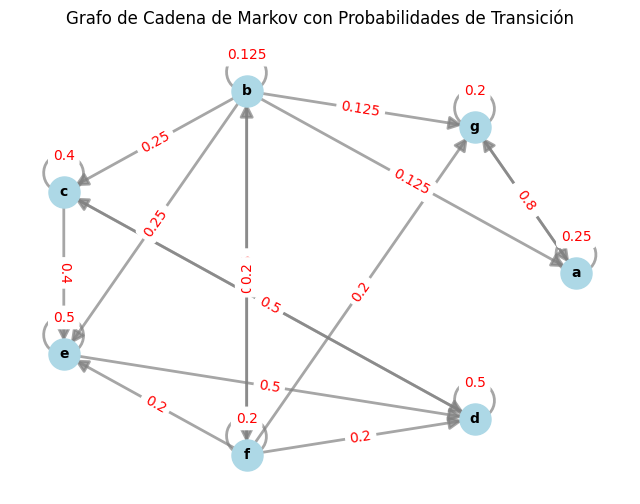

In [ ]:
G=nx.DiGraph() #grafo dirigido
# Definir los estados de la cadena de Markov
estados = ['a', 'b', 'c','d','e','f','g']

# (estado_origen, estado_destino, probabilidad)
trans = [
    ('a', 'a', 0.25),
    ('a', 'g', 0.75),
    ('b', 'a', 0.125),
    ('b', 'b', 0.125),
    ('b', 'c', 0.25),
    ('b', 'e', 0.25),
    ('b', 'f', 0.125),
    ('b', 'g', 0.125),
    ('c', 'c', 0.4),
    ('c', 'd', 0.2),
    ('c', 'e', 0.4),
    ('d', 'c', 0.5),
    ('d', 'd', 0.5),
    ('e', 'd', 0.5),
    ('e', 'e', 0.5),
    ('f', 'b', 0.2),
    ('f', 'd', 0.2),
    ('f', 'e', 0.2),
    ('f', 'f', 0.2),
    ('f', 'g', 0.2),
    ('g', 'a', 0.8),
    ('g', 'g', 0.2)
]

for origen, destino, proba in trans:
    G.add_edge(origen, destino, weight=proba)

# Visualizar el grafo
pos = nx.circular_layout(G)

plt.figure(figsize=(8, 6))

nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Dibujar las aristas
nx.draw_networkx_edges(G, pos, edgelist=G.edges(),
                       arrowsize=20, width=2, edge_color='gray', alpha=0.7)

# Obtener las etiquetas de las aristas (probabilidades)
edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title('Grafo de Cadena de Markov con Probabilidades de Transición')
plt.axis('off') # Ocultar los ejes
plt.show()

#2. Determine si la matriz tiene o no distribución límite

Veamos si la matriz es regular

In [ ]:
P3=P**3
pprint(P3.evalf(4))

⎡0.4356     0       0       0      0        0     0.5644⎤
⎢                                                       ⎥
⎢0.1693  0.0132   0.1627  0.275  0.2114  0.0132   0.1552⎥
⎢                                                       ⎥
⎢  0        0     0.294   0.422  0.284      0       0   ⎥
⎢                                                       ⎥
⎢  0        0     0.355   0.365   0.28      0       0   ⎥
⎢                                                       ⎥
⎢  0        0      0.35   0.425  0.225      0       0   ⎥
⎢                                                       ⎥
⎢0.1384  0.02113  0.1963  0.258  0.1842  0.02113  0.1809⎥
⎢                                                       ⎥
⎣0.602      0       0       0      0        0     0.398 ⎦


In [ ]:
PN=P**100000
pprint(PN.evalf(4))

⎡0.5161       0          0       0       0          0        0.4839⎤
⎢                                                                  ⎥
⎢0.172   8.339e-48813  0.2222  0.2667  0.1778  8.339e-48813  0.1613⎥
⎢                                                                  ⎥
⎢  0          0        0.3333   0.4    0.2667       0          0   ⎥
⎢                                                                  ⎥
⎢  0          0        0.3333   0.4    0.2667       0          0   ⎥
⎢                                                                  ⎥
⎢  0          0        0.3333   0.4    0.2667       0          0   ⎥
⎢                                                                  ⎥
⎢0.172   1.334e-48812  0.2222  0.2667  0.1778  1.334e-48812  0.1613⎥
⎢                                                                  ⎥
⎣0.5161       0          0       0       0          0        0.4839⎦


La matriz es no regular, ya que todas las entradas de la matriz no son mayores a cero para $P^n>0$ para algún $n\geq 1$. Entonces no tiene distribución límite.

In [ ]:
from sympy import symbols,solve

In [ ]:
x,y,z,w,u,v,t=symbols('x,y,z,w,u,v,t')
eq1=x-(P[0,0]*x+P[1,0]*y+P[6,0]*t)
eq2=y-(P[1,1]*y+P[5,1]*v)
eq3=z-(P[1,2]*y+P[2,2]*z+P[3,2]*w)
eq4=w-(P[2,3]*z+P[3,3]*w+P[4,3]*u+P[5,3]*v)
eq5=u-(P[1,4]*y+P[2,4]*z+P[4,4]*u+P[5,4]*v)
eq6=v-(P[1,5]*y+P[5,5]*v)
eq7=t-(P[0,6]*x+P[1,6]*y+P[5,6]*v+P[6,6]*t)
eq8=x+y+z+w+u+v+t-1
sol=solve([eq1,eq2,eq3,eq4,eq5,eq6,eq8],(x,y,z,w,u,v,t))
nsimplify(sol)

{u: 4/15 - 124*t/225, v: 0, w: 2/5 - 62*t/75, x: 16*t/15, y: 0, z: 1/3 - 31*t/45}

# 3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

**Estado recurrente**: El estado j es recurrente si la CM iniciada en j eventualmente regresa a j.

**Estado transiorio**: El estado j es trsnsiorio si existe probabilidad positiva de que la CM iniciada en j nunca regrese a j.

El espacio de estados de una CM finita puede ser particionada en estados transitorios T y estados recurrentes $R_i$, asi

$$S=T\cup R_1\cup \cdots \cup R_m$$

Esto permite reordenar la matriz de transición

$$
P = \begin{pmatrix}
*&* & \cdots & * \\
0 & P_1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & P_m
\end{pmatrix}
$$

Donde las columnas se llena $i=[\text{T},R_1,\cdots, R_m]$

Y las filas: $j=[\text{T}, R_1 ,\cdots, R_m]$

Clases

{b,f} es transitoria

{g,a} es recurrente

{c,d,e} es recurrente

$$T=\{b,f\}, R_1=\{a,g\},R_2=\{c,d,e\}$$

$$S=T\cup R_1\cup R_2$$

##Descomposición canónica de la matriz

Matriz canónica

$$P=\begin{pmatrix}
Q&R\\
0&I'\\
\end{pmatrix}$$

donde Q son transiciones entre transitorios, R de transitorios a recurrentes, e I' son las matrices de transición dentro de cada clase recurrente

In [ ]:
from sympy import Matrix, Rational
P1=Matrix([[1/8,1/8,1/8,1/8,1/4,0,1/4],[1/5,1/5,0,1/5,0,1/5,1/5],[0,0,1/4,3/4,0,0,0],[0,0,4/5,1/5,0,0,0],[0,0,0,0,2/5,1/5,2/5],[0,0,0,0,1/2,1/2,0],[0,0,0,0,0,1/2,1/2]])
pprint(P1.evalf(4))

⎡0.125  0.125  0.125  0.125  0.25   0   0.25⎤
⎢                                           ⎥
⎢ 0.2    0.2     0     0.2    0    0.2  0.2 ⎥
⎢                                           ⎥
⎢  0      0    0.25   0.75    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0     0.8    0.2    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.4   0.2  0.4 ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.5   0.5   0  ⎥
⎢                                           ⎥
⎣  0      0      0      0     0    0.5  0.5 ⎦


## Límite de la potencia n-esima de la matriz

In [ ]:
PN=P1**100000
pprint(PN.evalf(4))

⎡8.339e-48813  8.339e-48813  0.172   0.1613  0.2222  0.2667  0.1778⎤
⎢                                                                  ⎥
⎢1.334e-48812  1.334e-48812  0.172   0.1613  0.2222  0.2667  0.1778⎥
⎢                                                                  ⎥
⎢     0             0        0.5161  0.4839    0       0       0   ⎥
⎢                                                                  ⎥
⎢     0             0        0.5161  0.4839    0       0       0   ⎥
⎢                                                                  ⎥
⎢     0             0          0       0     0.3333   0.4    0.2667⎥
⎢                                                                  ⎥
⎢     0             0          0       0     0.3333   0.4    0.2667⎥
⎢                                                                  ⎥
⎣     0             0          0       0     0.3333   0.4    0.2667⎦


## Distribuciones límite de las submatrices.

Submatriz Q



In [ ]:
Q=Matrix([[0.125,0.125],[0.2,0.2]])
pprint(Q)

⎡0.125  0.125⎤
⎢            ⎥
⎣ 0.2    0.2 ⎦


Submatriz R

In [ ]:
R=Matrix([[1/8,1/8,1/4,0,1/4],[0,1/5,0,1/5,1/5]])
pprint(R)

⎡0.125  0.125  0.25   0   0.25⎤
⎢                             ⎥
⎣  0     0.2    0    0.2  0.2 ⎦


Bloque recurrente

$R_1=\{a,g\}$

In [ ]:
PR1=Matrix([[1/4,3/4],[4/5,1/5]])
pprint(PR1)

⎡0.25  0.75⎤
⎢          ⎥
⎣0.8   0.2 ⎦


In [ ]:
PR1N=PR1**100000
pprint(PR1N.evalf(4))

⎡0.5161  0.4839⎤
⎢              ⎥
⎣0.5161  0.4839⎦


$R_2=\{c,d,e\}$

In [ ]:
PR2=Matrix([[2/5,1/5,2/5],[1/2,1/2,0],[0,1/2,1/2]])
pprint(PR2)

⎡0.4  0.2  0.4⎤
⎢             ⎥
⎢0.5  0.5   0 ⎥
⎢             ⎥
⎣ 0   0.5  0.5⎦


In [ ]:
PR2N=PR2**100000
pprint(PR2N.evalf(4))

⎡0.3333  0.4  0.2667⎤
⎢                   ⎥
⎢0.3333  0.4  0.2667⎥
⎢                   ⎥
⎣0.3333  0.4  0.2667⎦


Coincide con la evolución de la matriz original cuando tiende a infinito.

Como la cadena tiene dos clases recurrentes cerradas. Hay infinitas distribuciones estacionarias.

CLASE $R_1$

In [ ]:
eq1=x-(0.25*x+0.8*y)
eq2=y-(0.75*x+0.2*y)
eq3=x+y-1
sol=solve([eq1,eq3],(x,y))
nsimplify(sol)

{x: 16/31, y: 15/31}

$$\pi^1=\Big(\frac{16}{31},\frac{15}{31}\Big) \text{en orden (a,g)}$$

CLASE $R_2$

In [ ]:
eq1=x-(0.4*x+0.5*y)
eq2=y-(0.2*x+0.5*y+0.5*z)
eq3=z-(0.4*x+0.5*z)
eq4=x+y-1
sol=solve([eq1,eq2,eq4],(x,y,z))
nsimplify(sol)

{x: 5/11, y: 6/11, z: 4/11}

$$\pi^2=\Big(\frac{5}{11},\frac{6}{11},\frac{4}{11}\Big) \text{en orden (c,d,e)}$$

Distribuciones estacionarias

$$\pi=\alpha\Big(\frac{16}{31},0,0,0,0,0,\frac{15}{31})+\beta \Big(0,0,\frac{5}{11},\frac{6}{11},\frac{4}{11},0,0\Big) $$

con $$\alpha,\beta \geq 0 \qquad α+\beta=1 $$

#4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.

In [ ]:
import numpy as np
from collections import defaultdict

In [ ]:
def encontrar_clases_comunicantes(matriz_transicion):
    cantidad_estados = len(matriz_transicion)

    # Construir grafo de accesibilidad:
    # para cada estado i, guardamos el conjunto de estados j a los que puede ir
    grafo_accesibilidad = defaultdict(set)
    for i in range(cantidad_estados):
        for j in range(cantidad_estados):
            if matriz_transicion[i][j] > 0:
                grafo_accesibilidad[i].add(j)

    # Función para primera pasada (grafo original)
    def dfs_primera_pasada(nodo, visitados, pila):
        visitados.add(nodo)
        for vecino in grafo_accesibilidad[nodo]:
            if vecino not in visitados:
                dfs_primera_pasada(vecino, visitados, pila)
        pila.append(nodo)  # Agregamos al terminar (post-orden)

    # Función para obtener el grafo transpuesto (invertir flechas)
    def obtener_grafo_transpuesto():
        grafo_transpuesto = defaultdict(set)
        for origen in grafo_accesibilidad:
            for destino in grafo_accesibilidad[origen]:
                grafo_transpuesto[destino].add(origen)
        return grafo_transpuesto

    # Función DFS para segunda pasada (grafo transpuesto)
    def dfs_segunda_pasada(nodo, visitados, componente_actual):
        visitados.add(nodo)
        componente_actual.add(nodo)
        for vecino in grafo_transpuesto[nodo]:
            if vecino not in visitados:
                dfs_segunda_pasada(vecino, visitados, componente_actual)

    # PRIMERA PASADA: ordenar por tiempo de finalización
    visitados = set()
    pila_orden = []

    for estado in range(cantidad_estados):
        if estado not in visitados:
            dfs_primera_pasada(estado, visitados, pila_orden)

    # SEGUNDA PASADA: encontrar componentes en grafo transpuesto
    grafo_transpuesto = obtener_grafo_transpuesto()
    visitados = set()
    clases_comunicantes = []

    # Procesamos en orden inverso al de finalización
    while pila_orden:
        estado_actual = pila_orden.pop()
        if estado_actual not in visitados:
            nueva_componente = set()
            dfs_segunda_pasada(estado_actual, visitados, nueva_componente)
            clases_comunicantes.append(nueva_componente)

    return clases_comunicantes

In [ ]:
def clasificar_estados(matriz_transicion, clases_comunicantes):

    cantidad_estados = len(matriz_transicion)
    clases_recurrentes = []
    estados_transitorios = set()

    # Para cada clase, verificamos si es cerrada (recurrente) o abierta (transitoria)
    for clase_actual in clases_comunicantes:
        es_clase_cerrada = True

        # Revisamos si desde algún estado de la clase se puede salir
        for estado in clase_actual:
            for posible_destino in range(cantidad_estados):
                # Si hay transición a un estado fuera de la clase
                if matriz_transicion[estado][posible_destino] > 0 and posible_destino not in clase_actual:
                    es_clase_cerrada = False
                    break
            if not es_clase_cerrada:
                break

        if es_clase_cerrada:
            # Si es cerrada, no se puede salir -> recurrente
            clases_recurrentes.append(clase_actual)
        else:
            # Si no es cerrada, se puede salir -> transitoria
            estados_transitorios.update(clase_actual)

    return estados_transitorios, clases_recurrentes

In [ ]:
def descomposicion_canonica(matriz_transicion, etiquetas_estados=None):

    cantidad_estados = len(matriz_transicion)

    # Etiquetas por defecto xd
    if etiquetas_estados is None:
        etiquetas_estados = [f'E{i}' for i in range(cantidad_estados)]

    # Paso 1: Encontrar clases comunicantes
    print("\n--- Paso 1: Buscando clases comunicantes ---")
    clases = encontrar_clases_comunicantes(matriz_transicion)
    for i, clase in enumerate(clases):
        print(f"  Clase {i+1}: {[etiquetas_estados[j] for j in clase]}")

    # Paso 2: Clasificar estados en transitorios y recurrentes
    print("\n--- Paso 2: Clasificando estados ---")
    estados_transitorios, clases_recurrentes = clasificar_estados(matriz_transicion, clases)
    print(f"  Estados transitorios: {[etiquetas_estados[i] for i in estados_transitorios]}")
    for i, clase in enumerate(clases_recurrentes):
        print(f"  Clase recurrente {i+1}: {[etiquetas_estados[j] for j in clase]}")

    # Paso 3: Crear el nuevo orden (transitorios primero, luego recurrentes)
    print("\n--- Paso 3: Reordenando matriz a forma canónica ---")
    nuevo_orden = list(estados_transitorios)
    for clase in clases_recurrentes:
        nuevo_orden.extend(list(clase))

    # Crear matriz en forma canónica
    matriz_canonica = np.zeros((cantidad_estados, cantidad_estados))
    nuevas_etiquetas = [etiquetas_estados[i] for i in nuevo_orden]

    # Llenar la nueva matriz
    for i_nuevo, i_original in enumerate(nuevo_orden):
        for j_nuevo, j_original in enumerate(nuevo_orden):
            matriz_canonica[i_nuevo][j_nuevo] = matriz_transicion[i_original][j_original]

    # Calcular índices en el nuevo orden
    cantidad_transitorios = len(estados_transitorios)
    indices_transitorios = list(range(cantidad_transitorios))

    indices_recurrentes = []
    indice_inicio = cantidad_transitorios
    for clase in clases_recurrentes:
        indice_fin = indice_inicio + len(clase)
        indices_recurrentes.append(list(range(indice_inicio, indice_fin)))
        indice_inicio = indice_fin

    print(f"  Nuevo orden de estados: {nuevas_etiquetas}")

    return matriz_canonica, nuevo_orden, indices_transitorios, indices_recurrentes, nuevas_etiquetas

In [ ]:
def imprimir_forma_canonica(matriz_transicion, etiquetas_estados=None):
    # Obtener la descomposición
    matriz_canonica, nuevo_orden, indices_transitorios, indices_recurrentes, nuevas_etiquetas = \
        descomposicion_canonica(matriz_transicion, etiquetas_estados)

    cantidad_transitorios = len(indices_transitorios)

    print("\n" + "=" * 70)
    print("RESULTADOS FINALES: DESCOMPOSICIÓN CANÓNICA")
    print("=" * 70)

    # Mostrar la partición del espacio de estados
    print("\n PARTICIPACIÓN DEL ESPACIO DE ESTADOS:")
    print(f"   S = T ∪ R₁ ∪ R₂ ∪ ... ∪ Rₘ")
    print(f"   T  (transitorios) = {{{', '.join([nuevas_etiquetas[i] for i in indices_transitorios])}}}")
    for indice, clase in enumerate(indices_recurrentes):
        print(f"   R{indice+1} (recurrentes) = {{{', '.join([nuevas_etiquetas[j] for j in clase])}}}")

    # Mostrar la matriz completa en forma canónica
    print("\n MATRIZ EN FORMA CANÓNICA:")
    print("   (Formato: [Q  R]")
    print("             [0  S])")
    print()

    # Encabezado de columnas
    encabezado = "        " + "    ".join([f"{et:>6}" for et in nuevas_etiquetas])
    print(encabezado)
    print("      " + "-" * (7 * len(nuevas_etiquetas)))

    # Filas de la matriz
    for i, fila in enumerate(matriz_canonica):
        fila_str = "    ".join([f"{val:6.4f}" if val > 0 else " 0.0000" for val in fila])
        print(f"{nuevas_etiquetas[i]:>4} | [{fila_str}]")

    # Mostrar los bloques por separado
    if cantidad_transitorios > 0:
        print(f"\n BLOQUE Q ({cantidad_transitorios}x{cantidad_transitorios}):")
        print("   Transiciones entre estados transitorios")
        bloque_q = matriz_canonica[:cantidad_transitorios, :cantidad_transitorios]
        for i, fila in enumerate(bloque_q):
            print(f"   {nuevas_etiquetas[i]}: {[f'{val:.4f}' for val in fila]}")

        print(f"\n BLOQUE R ({cantidad_transitorios}x{len(nuevo_orden) - cantidad_transitorios}):")
        print("   Transiciones de estados transitorios a recurrentes")
        bloque_r = matriz_canonica[:cantidad_transitorios, cantidad_transitorios:]
        for i, fila in enumerate(bloque_r):
            etiquetas_destino = nuevas_etiquetas[cantidad_transitorios:]
            fila_dict = {et: f'{val:.4f}' for et, val in zip(etiquetas_destino, fila) if val > 0}
            print(f"   {nuevas_etiquetas[i]} -> {fila_dict}")

    print(f"\n BLOQUE 0:")
    print("   Transiciones de estados recurrentes a transitorios")
    print("   (Siempre es una matriz de ceros)")

    print(f"\n BLOQUE S ({len(nuevo_orden) - cantidad_transitorios}x{len(nuevo_orden) - cantidad_transitorios}):")
    print("   Transiciones entre estados recurrentes (estructura diagonal por clases)")
    bloque_s = matriz_canonica[cantidad_transitorios:, cantidad_transitorios:]
    etiquetas_recurrentes = nuevas_etiquetas[cantidad_transitorios:]
    for i, fila in enumerate(bloque_s):
        print(f"   {etiquetas_recurrentes[i]}: {[f'{val:.4f}' for val in fila]}")

    # Mostrar matriz de cada clase recurrente
    print("\n CLASES RECURRENTES POR SEPARADO:")
    for indice_clase, clase in enumerate(indices_recurrentes):
        etiquetas_clase = [nuevas_etiquetas[j] for j in clase]
        print(f"\n   Clase recurrente R{indice_clase+1}: {etiquetas_clase}")
        print(f"   Matriz de transición interna:")
        # Extraer la submatriz de esta clase
        for i_global in clase:
            fila = []
            for j_global in clase:
                fila.append(matriz_canonica[i_global][j_global])
            print(f"   {nuevas_etiquetas[i_global]}: {[f'{val:.4f}' for val in fila]}")

    return matriz_canonica, nuevas_etiquetas, indices_transitorios, indices_recurrentes

In [ ]:
print("PROGRAMA DE DESCOMPOSICIÓN CANÓNICA DE CADENAS DE MARKOV")
# Matriz de transición del problema (7 estados: a, b, c, d, e, f, g)
# Etiquetas de los estados
etiquetas = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

# Ejecutar la descomposición canónica
matriz_canonica, etiquetas_nuevas, indices_trans, indices_rec = \
imprimir_forma_canonica(np.array(P), etiquetas)

PROGRAMA DE DESCOMPOSICIÓN CANÓNICA DE CADENAS DE MARKOV

--- Paso 1: Buscando clases comunicantes ---
  Clase 1: ['b', 'f']
  Clase 2: ['c', 'd', 'e']
  Clase 3: ['a', 'g']

--- Paso 2: Clasificando estados ---
  Estados transitorios: ['b', 'f']
  Clase recurrente 1: ['c', 'd', 'e']
  Clase recurrente 2: ['a', 'g']

--- Paso 3: Reordenando matriz a forma canónica ---
  Nuevo orden de estados: ['b', 'f', 'c', 'd', 'e', 'a', 'g']

RESULTADOS FINALES: DESCOMPOSICIÓN CANÓNICA

 PARTICIPACIÓN DEL ESPACIO DE ESTADOS:
   S = T ∪ R₁ ∪ R₂ ∪ ... ∪ Rₘ
   T  (transitorios) = {b, f}
   R1 (recurrentes) = {c, d, e}
   R2 (recurrentes) = {a, g}

 MATRIZ EN FORMA CANÓNICA:
   (Formato: [Q  R]
             [0  S])

             b         f         c         d         e         a         g
      -------------------------------------------------
   b | [0.1250    0.1250    0.2500     0.0000    0.2500    0.1250    0.1250]
   f | [0.2000    0.2000     0.0000    0.2000    0.2000     0.0000    0.2000]
   c 

In [ ]:
P=Matrix([[1/2,0,0,0,1/2],[1/3,1/2,1/6,0,0],[0,1/4,0,1/2,1/4],[0,0,0,1,0],[1,0,0,0,0]])
print("PROGRAMA DE DESCOMPOSICIÓN CANÓNICA DE CADENAS DE MARKOV")
# Matriz de transición del problema (7 estados: a, b, c, d, e, f, g)
# Etiquetas de los estados
etiquetas = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

# Ejecutar la descomposición canónica
matriz_canonica, etiquetas_nuevas, indices_trans, indices_rec = \
imprimir_forma_canonica(np.array(P), etiquetas)

PROGRAMA DE DESCOMPOSICIÓN CANÓNICA DE CADENAS DE MARKOV

--- Paso 1: Buscando clases comunicantes ---
  Clase 1: ['b', 'c']
  Clase 2: ['d']
  Clase 3: ['a', 'e']

--- Paso 2: Clasificando estados ---
  Estados transitorios: ['b', 'c']
  Clase recurrente 1: ['d']
  Clase recurrente 2: ['a', 'e']

--- Paso 3: Reordenando matriz a forma canónica ---
  Nuevo orden de estados: ['b', 'c', 'd', 'a', 'e']

RESULTADOS FINALES: DESCOMPOSICIÓN CANÓNICA

 PARTICIPACIÓN DEL ESPACIO DE ESTADOS:
   S = T ∪ R₁ ∪ R₂ ∪ ... ∪ Rₘ
   T  (transitorios) = {b, c}
   R1 (recurrentes) = {d}
   R2 (recurrentes) = {a, e}

 MATRIZ EN FORMA CANÓNICA:
   (Formato: [Q  R]
             [0  S])

             b         c         d         a         e
      -----------------------------------
   b | [0.5000    0.1667     0.0000    0.3333     0.0000]
   c | [0.2500     0.0000    0.5000     0.0000    0.2500]
   d | [ 0.0000     0.0000    1.0000     0.0000     0.0000]
   a | [ 0.0000     0.0000     0.0000    0.5000    0.5